In [ ]:
%pip install -U langgraph langchain langchain-openai langchain-tavily tavily-python python-dotenv

  Using cached langchain_tavily-0.2.11-py3-none-any.whl.metadata (22 kB)
  Using cached tavily_python-0.7.11-py3-none-any.whl.metadata (7.5 kB)
Using cached langchain_tavily-0.2.11-py3-none-any.whl (26 kB)
Using cached tavily_python-0.7.11-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-tavily]
Note: you may need to restart the kernel to use updated packages.


In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch()

# 直接调用工具
# .invoke() 方法是 LangChain Runnable 接口的标准执行方法
search_results = tool.invoke({"query": "What is LangGraph?"})

# 打印结果
import json

print(json.dumps(search_results, indent=2))

{
  "query": "What is LangGraph?",
  "follow_up_questions": null,
  "answer": null,
  "images": [],
  "results": [
    {
      "url": "https://www.ibm.com/think/topics/langgraph",
      "title": "What is LangGraph?",
      "content": "LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent\u2019s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced 

In [5]:
import os

os.environ["OPENAI_API_KEY"] = "sk-**********************"
os.environ["OPENAI_BASE_URL"] = "https://dashscope.aliyuncs.com/compatible-mode/v1"
os.environ["OPENAI_MODEL"] = "qwen-turbo"
os.environ["TAVILY_API_KEY"] = "tvly-3*****************"

In [6]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL"),  # 若走原生 OpenAI，可传 None/不传
    temperature=0.2,  # 稳定输出
    timeout=1200,  # 超时保护（秒）
    max_retries=2,  # 简单重试
)

In [8]:
# 导入核心库
from typing import Annotated, Dict, List, TypedDict

# 用于调试
from langchain.globals import set_debug
from langchain_core.messages import BaseMessage
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langgraph.graph import END, StateGraph

In [10]:
# 实例化Tavily搜索工具，设置返回结果数量为4
# 这是一个专为Agent设计的工具，能提供高质量的搜索结果
tool = TavilySearch(max_results=4)

# 将工具放入一个列表中，这是LangChain Agent的标准格式
tools = [tool]

print("Tool defined: TavilySearch")

Tool defined: TavilySearch


In [11]:
class AgentState(TypedDict):
    # 用户的原始问题
    original_query: str
    # LLM规划后生成的子问题列表
    sub_queries: List[str]
    # 每个子问题对应的搜索结果
    # 结构为: {"sub_query_1": "results...", "sub_query_2": "results..."}
    search_results: Dict[str, str]
    # 最终生成的报告
    final_report: str
    # LangGraph内部需要的消息历史
    messages: Annotated[list, lambda x, y: x + y]


print("Graph state 'AgentState' defined.")

Graph state 'AgentState' defined.


In [19]:
# --- 定义规划节点 (Planner Node) ---


def planner_node(state: AgentState):
    print("---进入规划节点---")
    # 准备一个格式化的提示，引导LLM进行任务拆解
    prompt = f"""你是一个世界级的AI研究助理。你的任务是接收一个复杂的研究问题，并将其分解为一系列更小、更具体的、可独立搜索的子问题。
    请为以下用户问题生成一个子问题列表，以便于进行网络搜索。每个子问题都应该是清晰、简洁的。

    用户问题: {state['original_query']}
    
    请返回一个仅包含子问题列表的JSON数组。
    例如: ["问题1", "问题2", "问题3"]
    """

    # 调用LLM生成子问题
    response = llm.invoke(prompt)
    sub_queries = json.loads(response.content)
    print(f"生成的子问题: {sub_queries}")

    # 更新状态
    return {"sub_queries": sub_queries}


# --- 定义研究节点 (Research Node) ---


def research_node(state: AgentState):
    print("---进入研究节点---")
    sub_queries = state.get("sub_queries", [])
    if not sub_queries:
        print("[research] 没有子问题可搜索，直接返回")
        return {"search_results": {}}

    # 【关键点1】batch 输入使用 {"query": "..."} 的列表，而不是纯字符串列表
    payload = [{"query": q} for q in sub_queries]

    try:
        # 【关键点2】指定并发，避免串行过慢；有的环境需要显式给 config
        results = tool.batch(payload, config={"max_concurrency": min(8, len(payload))})
        print(
            f"[research] batch 返回 {len(results)} 条结果，类型示例: {type(results[0]) if results else None}"
        )
    except Exception as e:
        print(f"[research] batch 调用异常，改用逐条 invoke。错误: {repr(e)}")
        results = []
        for q in sub_queries:
            try:
                r = tool.invoke({"query": q})  # 也可用 tool.invoke(q)
                results.append(r)
            except Exception as e2:
                results.append({"error": repr(e2)})

    # 结果归一化为字符串，便于写入状态
    norm = {}
    for q, r in zip(sub_queries, results):
        # r 可能是 dict / pydantic 模型 / 字符串，做一次尽量友好的提取
        try:
            if isinstance(r, dict) and "results" in r:
                # 只抽取前几条的 url + content，避免把 raw_content 带太多
                items = r.get("results", [])[:4]
                snippet = "\n".join(
                    [f"- {it.get('url')}: {it.get('content')}" for it in items]
                )
                norm[q] = snippet or str(r)
            else:
                norm[q] = str(r)
        except Exception:
            norm[q] = str(r)

    print("[research] 所有子问题搜索完成。")
    return {"search_results": norm}


# --- 定义撰写节点 (Writer Node) ---


def writer_node(state: AgentState):
    print("---进入撰写节点---")
    original_query = state["original_query"]
    search_results = state["search_results"]

    # 将所有搜索结果格式化，作为LLM的上下文
    context = "\n\n".join(
        [
            f"关于 '{query}' 的研究结果:\n{result}"
            for query, result in search_results.items()
        ]
    )

    prompt = f"""你是一个专业的AI报告撰写员。你的任务是根据提供的原始问题和一系列相关的研究资料，撰写一份全面、深入、结构清晰的研究报告。
    请确保报告逻辑连贯，并充分利用所有提供的资料。

    原始问题: {original_query}

    研究资料:
    {context}

    请根据以上信息，生成最终的研究报告。
    """

    # 调用LLM生成最终报告
    response = llm.invoke(prompt)
    print("最终报告生成完毕。")

    # 更新状态
    return {"final_report": response.content}


print("Graph nodes (planner, research, writer) defined.")

Graph nodes (planner, research, writer) defined.


In [20]:
# 实例化StateGraph，并传入我们定义的状态类
workflow = StateGraph(AgentState)

# 添加节点到图中，每个节点都有一个唯一的名称
workflow.add_node("planner", planner_node)
workflow.add_node("researcher", research_node)
workflow.add_node("writer", writer_node)

# 设置图的入口点
workflow.set_entry_point("planner")

# 添加边，定义节点之间的连接关系
workflow.add_edge("planner", "researcher")
workflow.add_edge("researcher", "writer")

# 将撰写节点连接到图的终点
workflow.add_edge("writer", END)

# 编译图，生成一个可执行的Runnable对象
graph = workflow.compile()

print("Graph built and compiled successfully.")

Graph built and compiled successfully.


In [21]:
# 定义一个复杂的研究问题
query = "对比分析 LangChain 和 LangGraph 的主要区别及其各自的应用场景，并说明 LangGraph 为何更适合构建循环和有状态的 Agent。"

# 调用 graph.invoke() 来执行整个工作流
# 我们需要以字典形式传入初始状态，这里只需要提供原始问题
final_state = graph.invoke({"original_query": query})

# 打印最终生成的报告
from IPython.display import Markdown, display

display(Markdown(final_state["final_report"]))

---进入规划节点---
生成的子问题: ['LangChain 的核心功能和架构是什么？', 'LangGraph 的核心功能和架构是什么？', 'LangChain 的主要应用场景有哪些？', 'LangGraph 的主要应用场景有哪些？', 'LangChain 如何处理循环和有状态的流程？', 'LangGraph 如何处理循环和有状态的流程？', 'LangGraph 相比 LangChain 在状态管理方面有哪些优势？', 'LangGraph 的设计如何支持更复杂的 Agent 流程？']
---进入研究节点---
[research] batch 返回 8 条结果，类型示例: <class 'dict'>
[research] 所有子问题搜索完成。
---进入撰写节点---
最终报告生成完毕。


# 研究报告：对比分析 LangChain 与 LangGraph 的主要区别及其各自的应用场景，并说明 LangGraph 为何更适合构建循环和有状态的 Agent

## 一、引言

随着大型语言模型（LLM）技术的快速发展，构建基于 LLM 的应用程序成为 AI 领域的重要方向。LangChain 和 LangGraph 是两个在该领域中广泛应用的框架，它们分别代表了不同的设计理念和技术路径。

LangChain 是一个开源框架，旨在简化基于 LLM 的应用开发流程，提供模块化组件支持从开发到部署的全流程。而 LangGraph 则是 LangChain 生态系统中的一个重要扩展，专注于构建有状态、多参与者（Agent）的应用程序，特别适合处理需要循环和复杂状态管理的任务。

本报告将对 LangChain 和 LangGraph 进行深入对比分析，探讨它们的主要区别、适用场景，并重点阐述 LangGraph 在构建循环和有状态 Agent 方面的优势。

---

## 二、LangChain 的核心功能与架构

### 1. 核心功能

- **链（Chains）**：LangChain 提供了“链”这一核心概念，允许开发者将多个 LLM 调用和工具调用链接在一起，形成有序的任务序列。
- **代理（Agents）**：通过代理机制，LangChain 可以让 LLM 自主选择工具和执行步骤，实现更复杂的任务流程。
- **检索增强生成（RAG）**：支持从外部数据源（如数据库、文档）中提取信息，增强 LLM 的响应能力。
- **记忆（Memory）**：提供上下文记忆机制，使系统能够在多次交互中保持连贯性。
- **回调（Callbacks）**：用于记录、监控和流式传输 LangChain 操作中的事件，便于调试和性能优化。

### 2. 架构特点

- **模块化设计**：LangChain 的架构采用分层设计，包括 `langchain-core`、`langchain` 和 `langchain-community` 等核心组件。
- **有向无环图（DAG）结构**：LangChain 的工作流通常遵循 DAG 结构，任务按单一方向流动，不形成循环。
- **丰富的集成能力**：支持与外部 API、数据库等工具无缝集成，拓展了 LLM 的应用场景。

### 3. 主要应用场景

- **聊天机器人**：通过链和代理机制构建对话系统。
- **问答系统**：结合 RAG 技术，提高回答的准确性和相关性。
- **内容生成**：利用 LLM 的生成能力，自动创建文本内容。
- **摘要器**：对长文本进行总结，提取关键信息。
- **知识库管理**：通过检索和存储机制，构建知识管理系统。

---

## 三、LangGraph 的核心功能与架构

### 1. 核心功能

- **支持循环流**：LangGraph 允许定义包含循环的流程，这对于大多数代理架构至关重要。而基于 DAG 的解决方案则不支持循环流。
- **状态管理**：提供状态管理功能，允许代理在多个步骤之间存储和检索信息，适用于需要跟踪对话状态或游戏状态的应用。
- **多参与者支持**：支持多个代理相互交互，实现更复杂的工作流程。
- **可扩展性**：可以扩展到生产环境，支持大规模应用程序。
- **人机协作（Human-in-the-loop, HITL）**：允许在图执行过程中进行人工干预，确保代理行为符合预期。

### 2. 架构特点

- **图结构**：LangGraph 使用图结构来定义工作流，每个节点代表一个操作，边表示节点之间的依赖关系。
- **状态传递**：每次图执行时都会创建一个状态，该状态在节点之间传递，每个节点在执行后更新此内部状态。
- **条件分支与循环**：支持条件分支和循环，使用户能够构建具有分层或顺序决策模式的单代理或多代理设置。
- **持久化机制**：内置持久性功能，支持断点续跑和状态恢复。

### 3. 主要应用场景

- **对话代理**：构建能够与用户进行自然语言对话的代理，如客户服务代理或虚拟助手。
- **聊天机器人**：构建能够理解用户意图并提供相关响应的聊天机器人。
- **虚拟助手**：构建能够执行任务并提供帮助的虚拟助手，如日程安排或提醒服务。
- **游戏代理**：构建能够在游戏中做出智能决定的代理，如棋盘游戏或电子游戏中的 AI 角色。
- **数据分析**：构建实时处理和分析数据的应用程序，如欺诈检测或异常检测。

---

## 四、LangChain 与 LangGraph 的主要区别

| 对比维度 | LangChain | LangGraph |
|----------|-----------|-----------|
| **工作流结构** | 基于有向无环图（DAG），任务按单一方向流动 | 基于图结构，支持循环和条件分支 |
| **状态管理** | 支持基本的记忆机制，但不适用于复杂状态 | 提供强大的状态管理功能，支持多步骤状态更新 |
| **循环支持** | 不支持循环流 | 支持循环流，适合需要重复步骤的任务 |
| **多代理支持** | 有限支持，主要依赖代理机制 | 强大支持，支持多代理协作和交互 |
| **可控性** | 相对较低，流程较为固定 | 高度可控，支持细粒度的流程控制 |
| **适用场景** | 适用于简单到中等复杂度的任务，如聊天机器人、问答系统 | 适用于复杂、动态的任务，如多代理协作、游戏 AI、数据分析等 |

---

## 五、LangGraph 为何更适合构建循环和有状态的 Agent

### 1. 支持循环流

LangGraph 的图结构允许定义包含循环的流程，这使得它非常适合构建需要重复步骤或反馈循环的应用。例如，在多轮对话中，代理可以根据用户的输入不断调整策略，而不是一次性完成所有步骤。

### 2. 强大的状态管理

LangGraph 提供了状态管理功能，允许代理在多个步骤之间存储和检索信息。这种能力对于构建需要跟踪对话状态或游戏状态的应用至关重要。例如，在游戏代理中，代理可以记住当前的游戏状态，并根据状态变化做出相应的决策。

### 3. 多代理协作

LangGraph 支持多个代理相互交互，实现更复杂的工作流程。这种能力使得它非常适合构建需要协作或竞争的代理应用程序，如团队协作系统或多人游戏 AI。

### 4. 可控性和灵活性

LangGraph 提供了对代码流、提示词以及 LLM 调用的低级控制，赋予开发者对认知架构的精细控制能力。这种灵活性使得开发者可以构建更加复杂和智能的 Agent 系统。

### 5. 人机协作（HITL）

LangGraph 支持人在环机制，允许在图执行过程中进行人工干预。这对于需要人类输入或批准的应用程序特别有用，如医疗诊断、金融决策等高风险场景。

---

## 六、应用场景对比

| 应用场景 | LangChain 适用性 | LangGraph 适用性 |
|----------|------------------|------------------|
| 聊天机器人 | ✅ 适用于简单对话 | ✅ 更适合多轮对话和复杂交互 |
| 问答系统 | ✅ 适用于静态问题 | ✅ 更适合动态问题和上下文感知 |
| 内容生成 | ✅ 适用于单次生成 | ✅ 更适合迭代生成和优化 |
| 游戏 AI | ❌ 不适合 | ✅ 非常适合 |
| 数据分析 | ✅ 适用于简单分析 | ✅ 更适合实时处理和复杂逻辑 |
| 多代理协作 | ❌ 有限支持 | ✅ 强大支持 |

---

## 七、结论

LangChain 和 LangGraph 分别代表了两种不同的 LLM 应用开发范式。LangChain 以其模块化设计和丰富的集成能力，适合构建简单到中等复杂度的应用；而 LangGraph 则以其图结构、状态管理和多代理支持，更适合构建复杂、动态的 Agent 系统。

LangGraph 在构建循环和有状态的 Agent 方面具有显著优势，特别是在需要多轮交互、状态跟踪和复杂决策的场景中表现尤为突出。因此，对于需要构建高级 Agent 系统的应用，LangGraph 是更为合适的选择。

---

## 八、未来展望

随着 AI 技术的不断发展，LangGraph 作为 LangChain 生态系统的一部分，将继续演进，提供更多高级功能，如更强大的状态管理、更灵活的流程控制以及更高效的多代理协作机制。未来，LangGraph 有望在更多领域中发挥重要作用，推动 AI 应用的进一步发展。

In [16]:
conda install -c conda-forge graphviz pygraphviz

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 4.11.0
  latest version: 25.7.0

Please update conda by running

    $ conda update -n base conda



## Package Plan ##

  environment location: /Users/eumenides/miniforge3/envs/jupyter_env

  added / updated specs:
    - graphviz
    - pygraphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    adwaita-icon-theme-48.1    |           unix_1         607 KB  conda-forge
    atk-1.0-2.38.0             |       hd03087b_2         339 KB  conda-forge
    cairo-1.18.4               |       h6a3b0d2_0         875 KB  conda-forge
    epoxy-1.5.10               |       h1c322ee_1         347 KB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |       h77eed37_0          94 KB  conda-forge
    font-ttf-source-code-pro-2.038|   

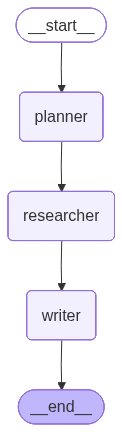

In [17]:
from IPython.display import Image

try:
    # 生成并显示图的可视化PNG图片
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"无法生成可视化图片，请确保已安装pygraphviz和graphviz: {e}")

In [18]:
from langchain_tavily import TavilySearch

s = TavilySearch(max_results=2)
print(s.invoke("What is Ethereum?"))

{'query': 'What is Ethereum?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://en.wikipedia.org/wiki/Ethereum', 'title': 'Ethereum - Wikipedia', 'content': 'Ethereum is a decentralized blockchain with smart contract functionality. Ether (abbreviation: ETH) is the native cryptocurrency of the platform.', 'score': 0.9184877, 'raw_content': None}, {'url': 'https://cointelegraph.com/learn/articles/what-is-ethereum-a-beginners-guide-to-eth-cryptocurrency', 'title': 'What is Ethereum and how does it work? - Cointelegraph', 'content': 'Ethereum Ethereum  Ethereum is a decentralized blockchain network powered by the Ether token that enables users to make transactions, earn interest on their holdings through staking, use and store nonfungible tokens (NFTs), trade cryptocurrencies, play games, use social media and so much more. If centralized platforms like Apple’s App Store represent Web 2.0, a decentralized, user-powered network like Ethereum is Web 3.0.